# 프로젝트 발표 자료: 도금욕 공정 데이터 분석 및 불량 예측 모델 개발

## 데이터 불러오기

In [ ]:
import pandas as pd
import holidays

df= pd.read_csv('/content/merged_output.csv')
error_data=pd.read_csv("/content/Error Lot list.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50094 entries, 0 to 50093
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Index    50094 non-null  int64  
 1   Lot      50094 non-null  int64  
 2   Time     50094 non-null  object 
 3   pH       50094 non-null  float64
 4   Temp     50094 non-null  float64
 5   Current  50094 non-null  float64
 6   Voltage  50094 non-null  float64
dtypes: float64(4), int64(2), object(1)
memory usage: 2.7+ MB


### 날짜 변수 datetime으로 변환

In [ ]:
#  시간 형식 변환
df['Time'] = df['Time'].str.replace('오후', 'PM').str.replace('오전', 'AM')
df['Time'] = pd.to_datetime(df['Time'], format='%p %I:%M:%S.%f').dt.floor('S').dt.time  # 소수점 이하 초 제거

# 한국 공휴일 및 주말 제외한 유효한 날짜 생성
kr_holidays = holidays.KR(years=[2021])
all_dates = pd.date_range(start='2021-09-06', end='2021-10-27')

# 주말과 공휴일을 제외한 날짜만 선택
valid_dates = [date for date in all_dates if date.weekday() < 5 and date not in kr_holidays]

# 날짜 변경 기준: 'Index'가 1로 리셋될 때마다 날짜 변경
date_index = 0
assigned_dates = []

for idx, row in df.iterrows():
    if row['Index'] == 1 and idx != 0:  # 새로운 Lot 시작 시 날짜 변경
        date_index += 1
    assigned_dates.append(valid_dates[date_index])

#  할당된 날짜를 데이터프레임에 추가
df['Assigned_Date'] = assigned_dates

# 날짜와 시간 결합 (datetime 형식 유지)
df['Datetime'] = pd.to_datetime(df['Assigned_Date'].astype(str) + ' ' + df['Time'].astype(str))
df.drop(columns='Assigned_Date',inplace=True)


<ipython-input-6-b939e4f076ae>:3: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['Time'] = pd.to_datetime(df['Time'], format='%p %I:%M:%S.%f').dt.floor('S').dt.time  # 소수점 이하 초 제거


## 불량 데이터, 정상 데이터 추출

In [ ]:

#  열 이름 변경 및 날짜 변환 (LoTf → Lot)
error_data = error_data.rename(columns={'LoT': 'Lot'})
df['Date'] = pd.to_datetime(df['Datetime']).dt.date
error_data['Date'] = pd.to_datetime(error_data['Date']).dt.date

#  공백인 Lot 처리: 공백인 경우는 정상 데이터로 간주
error_data = error_data[error_data['Lot'].notna()]

#  날짜와 Lot 기준으로 병합
merged_df = df.merge(error_data[['Date', 'Lot']], on=['Date', 'Lot'], how='left', indicator=True)

#.불량 데이터 제외: 병합된 데이터 중 '_merge'가 'both'인 데이터가 불량 데이터
cleaned_data = merged_df[merged_df['_merge'] == 'left_only'].drop(columns=['_merge', 'Date'])

#  결과 출력
print(f"불량 데이터 제외 전 데이터 크기: {len(df)}")
print(f"불량 데이터 제외 후 데이터 크기: {len(cleaned_data)}")

# 불량 데이터
defective_data = merged_df[merged_df['_merge'] == 'both'].drop(columns=['_merge', 'Date'])

불량 데이터 제외 전 데이터 크기: 50094
불량 데이터 제외 후 데이터 크기: 49197


## 데이터 분포 확인(박스 플롯, 히스토그램)

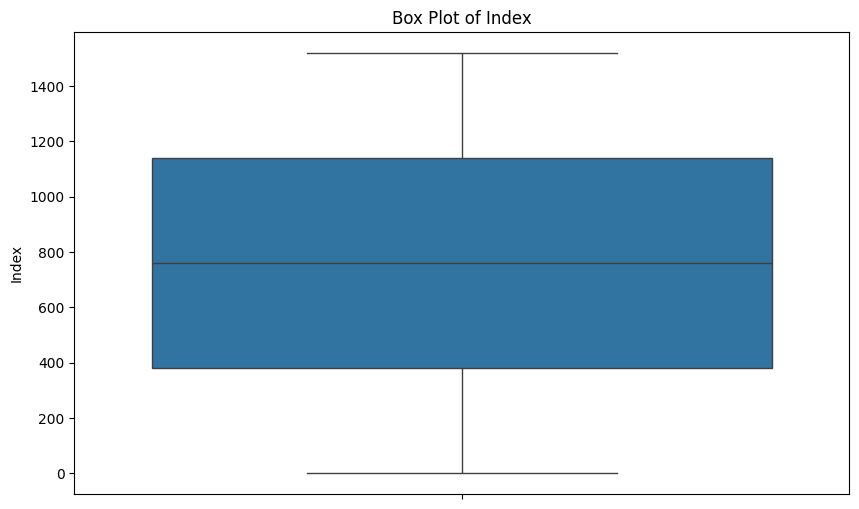

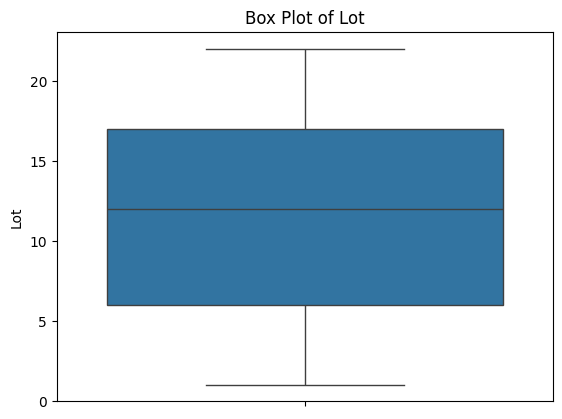

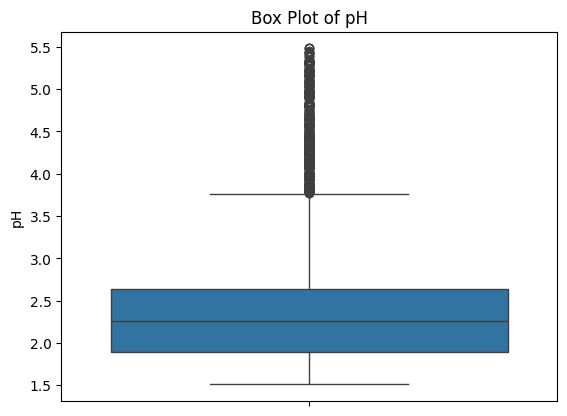

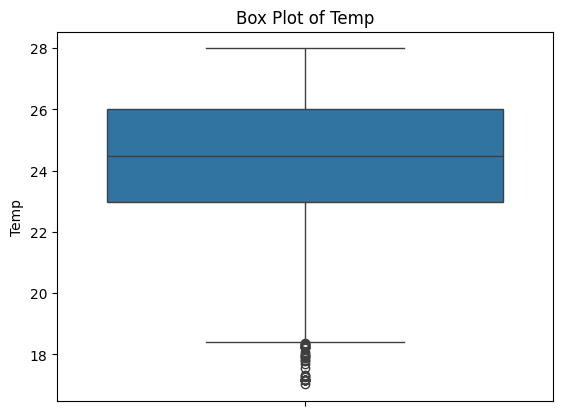

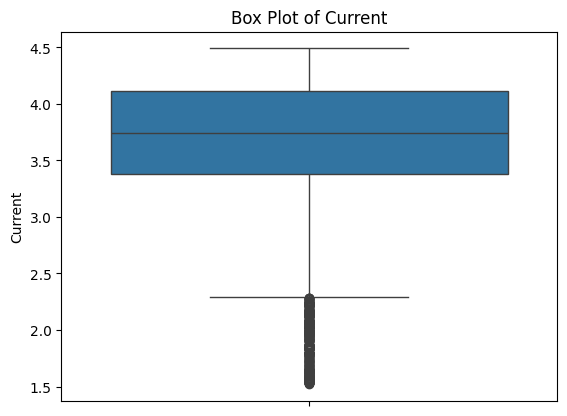

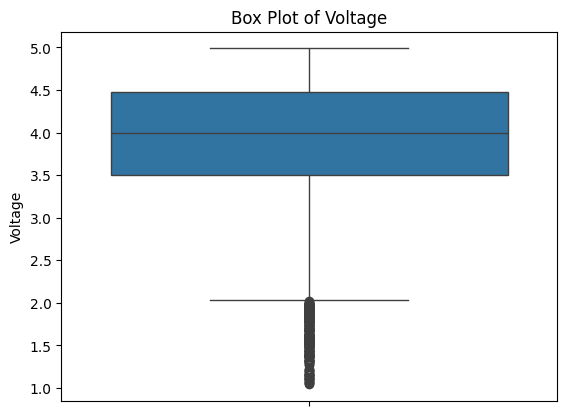

In [ ]:
# 정상 데이터 박스 플롯
import seaborn as sns
import matplotlib.pyplot as plt

# 수치형 변수 선택 및 박스 플롯 그리기
numeric_columns = cleaned_data.select_dtypes(include=['float64', 'int64']).columns

# 박스 플롯 시각화 (수치형 변수 전체)
plt.figure(figsize=(10, 6))
for col in numeric_columns:
    sns.boxplot(data=cleaned_data, y=col)
    plt.title(f'Box Plot of {col}')
    plt.show()


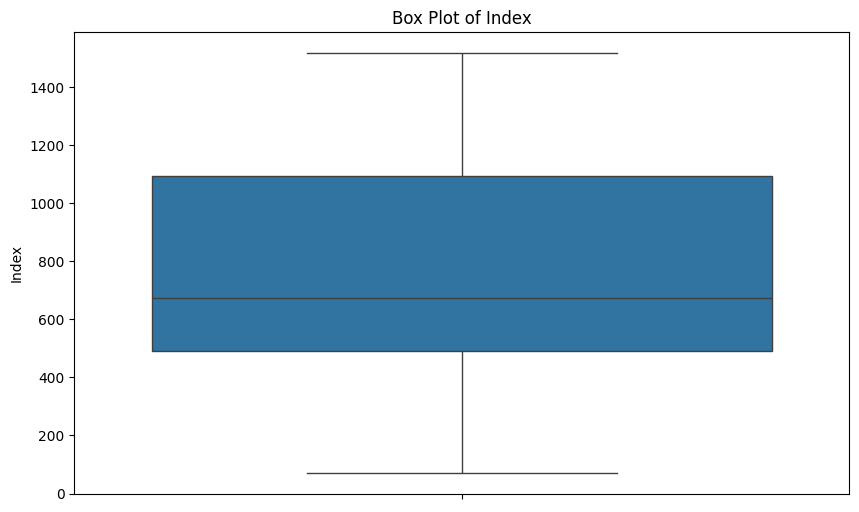

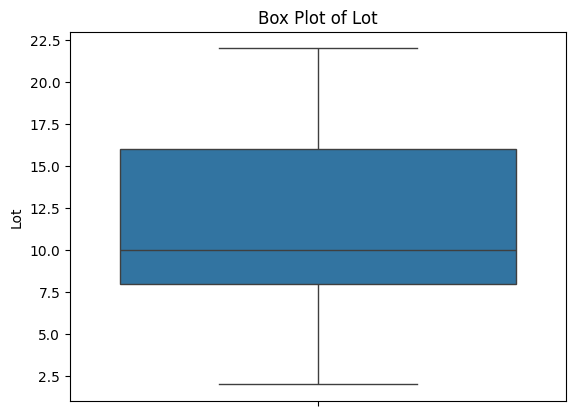

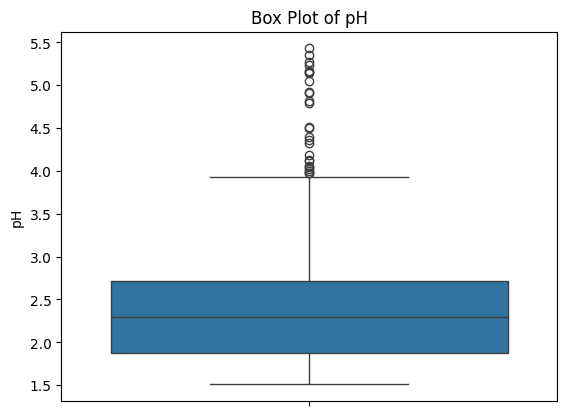

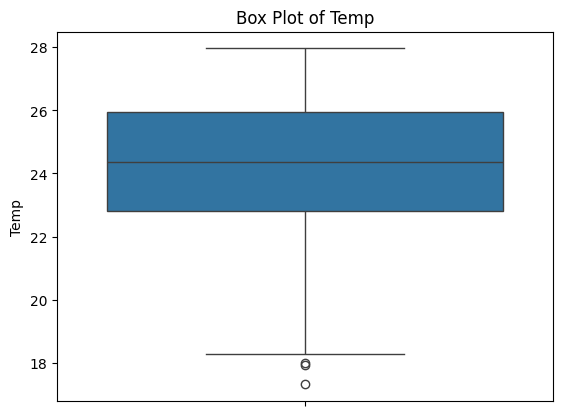

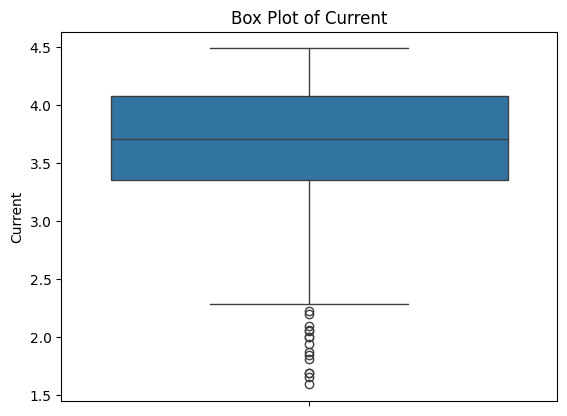

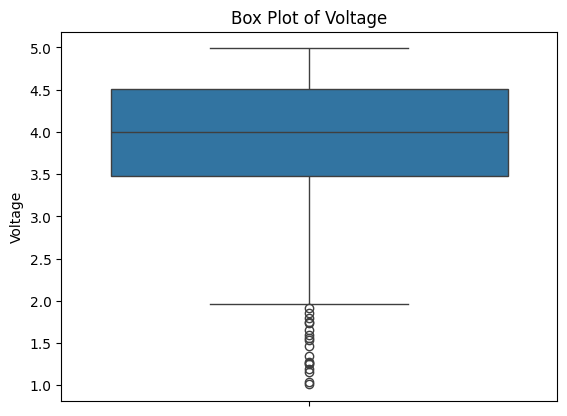

In [ ]:
# 불량 데이터 박스 플롯
import seaborn as sns
import matplotlib.pyplot as plt

# 수치형 변수 선택 및 박스 플롯 그리기
numeric_columns = defective_data.select_dtypes(include=['float64', 'int64']).columns

# 박스 플롯 시각화 (수치형 변수 전체)
plt.figure(figsize=(10, 6))
for col in numeric_columns:
    sns.boxplot(data=defective_data, y=col)
    plt.title(f'Box Plot of {col}')
    plt.show()

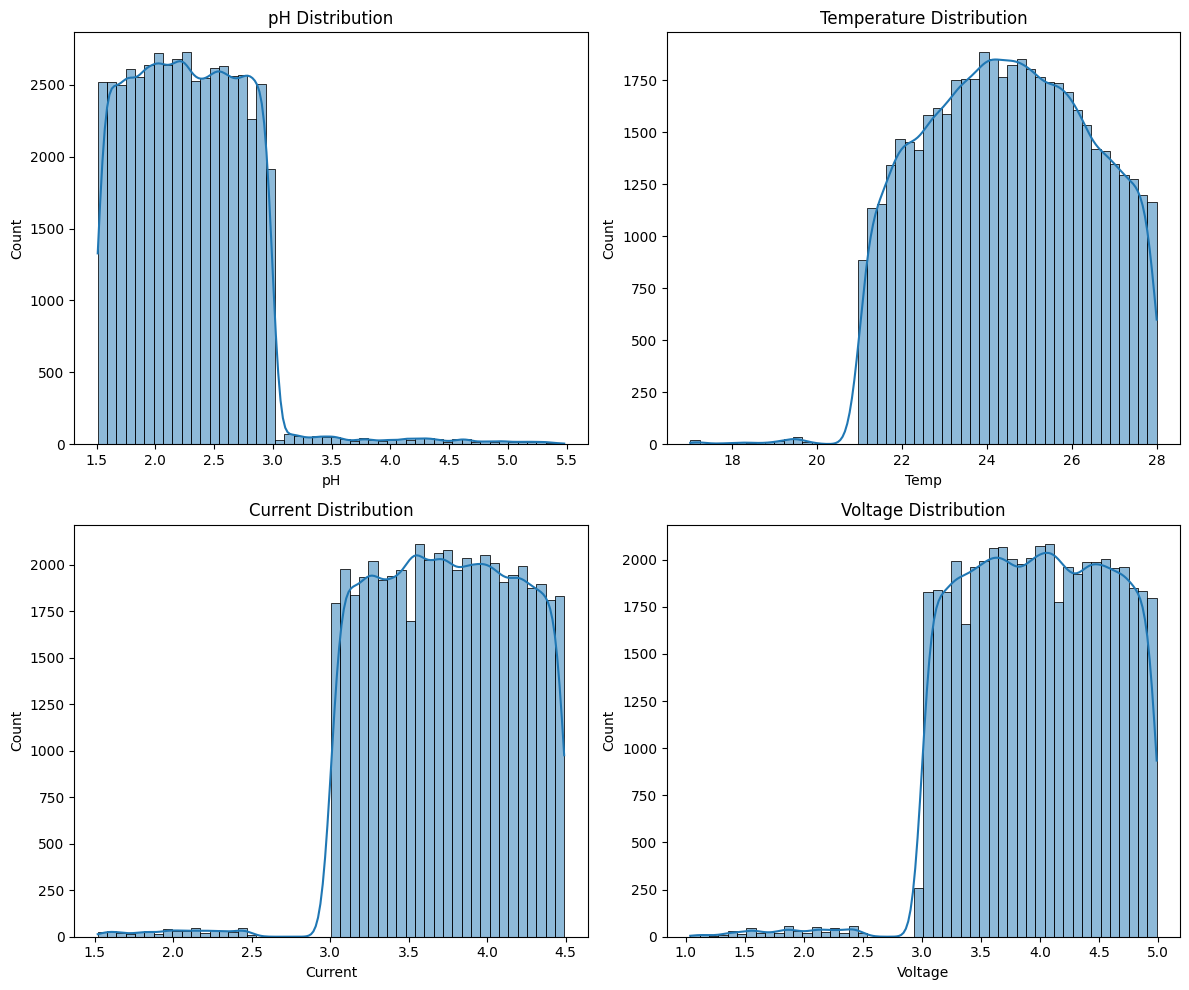

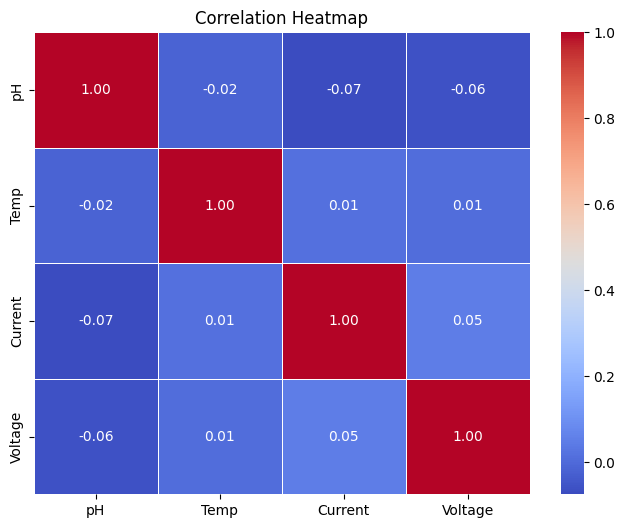

In [ ]:
# 정상 데이터 히스토그램
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(cleaned_data['pH'], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('pH Distribution')

sns.histplot(cleaned_data['Temp'], bins=50, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Temperature Distribution')

sns.histplot(cleaned_data['Current'], bins=50, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Current Distribution')

sns.histplot(cleaned_data['Voltage'], bins=50, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Voltage Distribution')

plt.tight_layout()
plt.show()

# 상관계수 히트맵
plt.figure(figsize=(8, 6))
sns.heatmap(cleaned_data[['pH', 'Temp', 'Current', 'Voltage']].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


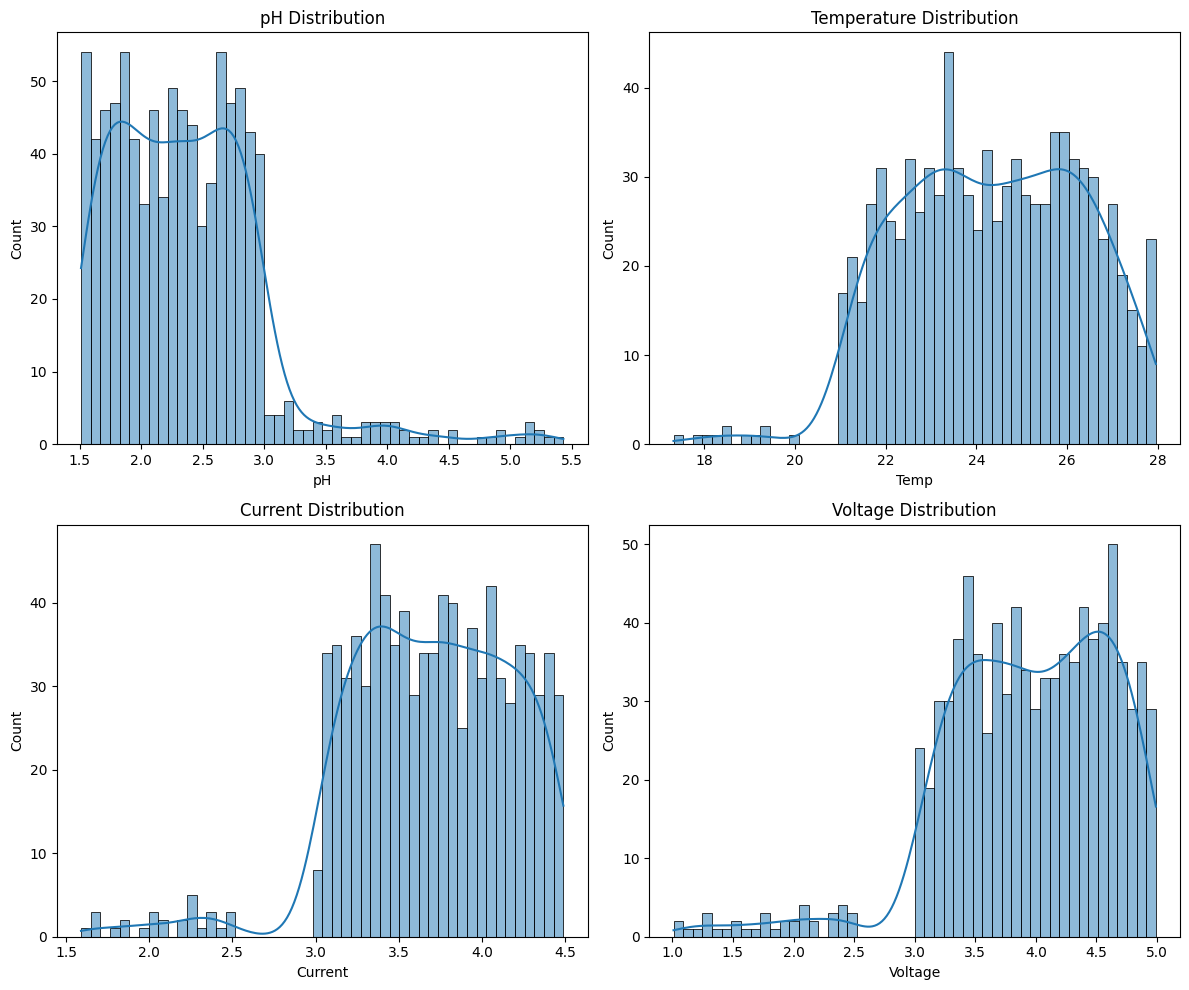

Text(0.5, 1.0, 'Correlation Heatmap')

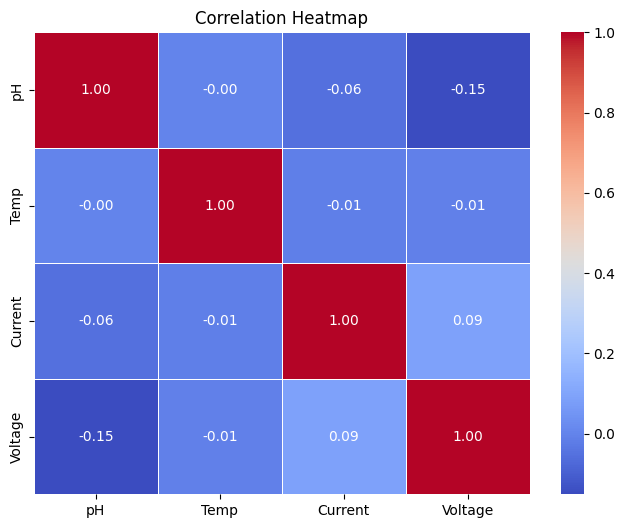

In [ ]:
import seaborn as sns
# 불량 데이터 히스토그램
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(defective_data['pH'], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('pH Distribution')

sns.histplot(defective_data['Temp'], bins=50, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Temperature Distribution')

sns.histplot(defective_data['Current'], bins=50, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Current Distribution')

sns.histplot(defective_data['Voltage'], bins=50, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Voltage Distribution')

plt.tight_layout()
plt.show()

# 상관계수 히트맵
plt.figure(figsize=(8, 6))
sns.heatmap(defective_data[['pH', 'Temp', 'Current', 'Voltage']].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')

## **pH 변수 설명**

---

### **1. 범위**  
- **평균:** 약 2.9  
- **최소값:** 1.51  
- **최대값:** 5.48  

---

### **2. 분포**  
- 대부분의 데이터가 **pH 1.5 ~ 3.0** 구간에 분포하고 있음.  
- 이는 정상적인 도금 공정이 이 범위 내에서 유지된다는 것을 시사함.

---

### **3. 도금욕에서의 pH 관리**
- **pH란:**  
  - pH는 **수용액의 산성도나 알칼리도를 나타내는 지표로, 0에서 14까지의 척도로 측정**됨.  
  - 도금욕의 pH는 **도금 유형과 목적에 따라 최적의 범위로 관리**되어야 함.

- **우리의 데이터:**  
  - 대부분의 pH가 **1.5 ~ 3.0** 사이에 위치하며, 이는 **강한 산성 환경**에서 공정이 이루어지고 있음을 의미함.

---

### **4. pH의 중요성**
- **금속 증착의 품질과 표면 마감에 큰 영향:**  
  - 도금욕의 pH는 **금속 이온의 이동과 증착 속도**에 직접적인 영향을 미치며,  
  - **pH가 정상 범위를 벗어나면 도금 두께 불균일, 결함 발생 등의 품질 저하**로 이어질 수 있음.

---

### **5. 불량 가능성과의 관계**
- **가설:**  
  - pH가 **정상 범위(1.5 ~ 3.0) 특히 3 이상일 때 불량 가능성이 높아질 것이라는 가설**을 세움.


## **Current, Voltage 변수 설명**

---

### **1. 도금욕 공정에서의 중요성**
- **전류 밀도(Current Density):**  
  - 도금 공정에서 전류 밀도는 **도금층의 두께와 균일성에 큰 영향을 미치는 중요한 요소** 중 하나임.  

---

### **2. 전류 밀도가 너무 낮을 때 발생하는 문제**
- **음극의 분극 감소:**  
  - 전류 밀도가 낮으면 **결정 입자가 굵어지고 도금층이 조밀하지 않음**.  

---

### **3. 전류 밀도가 너무 높을 때 발생하는 문제**
- **음극 부근의 금속 이온 부족:**  
  - 금속 이온이 충분히 공급되지 못해 **가지 모양(수지상) 도금층**이 형성되거나, **스펀지처럼 느슨한 구조**가 발생할 수 있음.  

---

### **4. 전류 밀도의 계산 및 전압과의 관계**
- **전류 밀도 = 전류 / 단면적**  
  - 전류 밀도는 보통 **전류의 직접 제어**로 설정되지만, **전압 제어 방식으로도 간접적으로 설정 가능**함.  
  - **전류 = 전압 * 저항**이라는 전기적 관계를 통해 전압과 전류는 공정 상태에 밀접하게 연결되어 있음.

---

### **5. Current/Voltage 비율의 중요성**
- **Current/Voltage 비율:**  
  - 전류와 전압의 비율은 **공정 상태를 직접적으로 나타내는 변수**임.  
  - **특정 비율을 벗어날 경우, 도금 공정의 불균형 및 불량 발생 가능성이 높아진다는 가설**을 세움.



## **Temp 변수 설명**

---

### **1. 도금 공정에서의 온도의 중요성**
- **온도는 금속 이온의 이동 속도와 반응 속도에 직접적인 영향을 미침.**  
  - 도금욕의 온도가 높으면 **금속 이온의 이동이 빨라지고 반응 속도가 증가**하지만, 지나치게 높으면 불균일한 도금층이 형성될 수 있음.  
  - 온도가 낮으면 **반응 속도가 느려져 도금층이 얇거나 고르지 않게 형성**될 수 있음.

---

### **2. 온도 변화가 도금 품질에 미치는 영향**
- **온도의 급격한 변화는 도금층의 결함을 유발할 수 있음.**  
  - 예를 들어, **온도 변화가 크면 금속 입자가 균일하게 증착되지 않고 표면 거칠기, 두께 불균일 등이 발생할 수 있음**.

- **시간에 따른 온도 변화량(Temp_diff)과 이상치 설정(Temp_anomaly)**을 통해 급격한 온도 변화가 불량에 미치는 영향을 분석함.

---

### **3. 가설 설정**
- **가설:** 시간에 따른 온도 변화량이 크거나 급격한 변화가 있을 경우 **도금 품질에 부정적인 영향을 미치고, 불량 발생 가능성이 높아진다**고 판단.  
  - **이상치 기준:** 온도 변화량이 **4°C 이상일 때 이상치(Temp_anomaly)로 간주**
---


### 라이브러리 불러옴

In [ ]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

### 정상 데이터와 불량 데이터를 구분하기 위해 타겟 변수를 추가하고, 시계열 데이터를 분석할 수 있도록 Datetime 변환

In [ ]:
cleaned_data['target'] = 0
defective_data['target'] = 1

cleaned_data['Datetime'] = pd.to_datetime(cleaned_data['Datetime'])
defective_data['Datetime'] = pd.to_datetime(defective_data['Datetime'])

### 도메인 지식 기반 파생 변수 생성

In [ ]:
def create_domain_features(data):
    data['Current/Voltage'] = data['Current'] / (data['Voltage'])  # 전류/전압 비율
    data['pH_diff'] = data['pH'].diff().fillna(0)  # pH 변화량

    # 이전 시간 정보를 현재 정보로
    data['prev_Current'] = data['Current'].shift(1).fillna(data['Current'])
    data['prev_Voltage'] = data['Voltage'].shift(1).fillna(data['Voltage'])
    data['prev_pH'] = data['pH'].shift(1).fillna(data['pH'])
    data['prev_Temp'] = data['Temp'].shift(1).fillna(data['Temp'])

    # 전류와 전압의 변화량
    data['Current_diff'] = data['Current'] - data['prev_Current']
    data['Voltage_diff'] = data['Voltage'] - data['prev_Voltage']

    # 온도 변화량과 급격한 변화 탐지
    data['Temp_diff'] = data['Temp'] - data['prev_Temp']
    data['Temp_anomaly'] = (abs(data['Temp_diff']) >= 4).astype(int)  #  표준편차가 1.2라 3배 이상인 4도 이상의 변화 시 이상치로 간주

    # 전류/전압의 이상치 여부 (정상 범위를 벗어나는 경우)
    data['Current_anomaly'] = ((data['Current'] < 3) | (data['Current'] > 5)).astype(int)
    data['Voltage_anomaly'] = ((data['Voltage'] < 3) | (data['Voltage'] > 5)).astype(int)

    # pH 이상치 여부 (정상 범위: 1.5 ~ 3.0)
    data['pH_anomaly'] = ((data['pH'] < 1.5) | (data['pH'] > 3.0)).astype(int)

    # anomaly 데이터 안에 이상 or 정상을 저장

    return data
# 도메인 지식 기반 파생 변수 생성 데이터
cleaned_data_domain = create_domain_features(cleaned_data)
defective_data_domain = create_domain_features(defective_data)

In [ ]:
cleaned_data_domain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49197 entries, 0 to 50093
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Index            49197 non-null  int64         
 1   Lot              49197 non-null  int64         
 2   Time             49197 non-null  object        
 3   pH               49197 non-null  float64       
 4   Temp             49197 non-null  float64       
 5   Current          49197 non-null  float64       
 6   Voltage          49197 non-null  float64       
 7   Datetime         49197 non-null  datetime64[ns]
 8   target           49197 non-null  int64         
 9   Current/Voltage  49197 non-null  float64       
 10  pH_diff          49197 non-null  float64       
 11  prev_Current     49197 non-null  float64       
 12  prev_Voltage     49197 non-null  float64       
 13  prev_pH          49197 non-null  float64       
 14  prev_Temp        49197 non-null  float64   

In [ ]:
defective_data_domain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 897 entries, 1587 to 46643
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Index            897 non-null    int64         
 1   Lot              897 non-null    int64         
 2   Time             897 non-null    object        
 3   pH               897 non-null    float64       
 4   Temp             897 non-null    float64       
 5   Current          897 non-null    float64       
 6   Voltage          897 non-null    float64       
 7   Datetime         897 non-null    datetime64[ns]
 8   target           897 non-null    int64         
 9   Current/Voltage  897 non-null    float64       
 10  pH_diff          897 non-null    float64       
 11  prev_Current     897 non-null    float64       
 12  prev_Voltage     897 non-null    float64       
 13  prev_pH          897 non-null    float64       
 14  prev_Temp        897 non-null    float64  

## 부족한 불량 데이터를 증강 및 최종 데이터 결합

In [ ]:
# sampling 함수 - 데이터를 5배로 증가, 노이즈는 2%
def sampling(data, num_augment=5, noise_level=0.02):
    samlping_data = [] # 증강 데이터를 저장한 리스트
    for _ in range(num_augment):
        sampled = data.copy()
        shift = np.random.randint(1, 6) * 5  # 5초 단위로 이동 , 랜덤으로 5초 단위의 시간이동(5-25초) , 다양한 시점의 데이터 제공 가능
        sampled['Datetime'] = sampled['Datetime'] + pd.to_timedelta(shift, unit='s')
        for col in ['pH', 'Temp', 'Current', 'Voltage']: # 각변수에 해당 샘플들을 추가
            sampled[col] += np.random.normal(0, noise_level, size=len(sampled)) # 각 변수들 마다의 노이즈를 2% 로 조정
        samlping_data.append(sampled)
    return pd.concat(samlping_data, ignore_index=True)

In [ ]:
# 함수를 실행 후 정상데이터, 불량데이터, 증강된 뷸량 데이터를 넣어준 후 최종 데이터를 만들어줌
augmented_defective_data = sampling(defective_data, num_augment=10)
final_data = pd.concat([cleaned_data_domain, defective_data_domain, augmented_defective_data], ignore_index=True)

In [ ]:
augmented_defective_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8970 entries, 0 to 8969
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Index            8970 non-null   int64         
 1   Lot              8970 non-null   int64         
 2   Time             8970 non-null   object        
 3   pH               8970 non-null   float64       
 4   Temp             8970 non-null   float64       
 5   Current          8970 non-null   float64       
 6   Voltage          8970 non-null   float64       
 7   Datetime         8970 non-null   datetime64[ns]
 8   target           8970 non-null   int64         
 9   Current/Voltage  8970 non-null   float64       
 10  pH_diff          8970 non-null   float64       
 11  prev_Current     8970 non-null   float64       
 12  prev_Voltage     8970 non-null   float64       
 13  prev_pH          8970 non-null   float64       
 14  prev_Temp        8970 non-null   float64

## 모델 생성 및 결과 검증

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# 성능 평가 함수 정의
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{model_name} 성능 평가")
    print("="* 50)

    # 정확도 출력
    accuracy = accuracy_score(y_true, y_pred)
    print(f"\n정확도: {accuracy:.4f}")

    # 분류 보고서 출력 (정밀도, 재현율, F1 점수 등)
    print("\n분류 보고서:")
    print(classification_report(y_true, y_pred))

    # 혼동 행렬 시각화
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_true, y_pred),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['impossible', 'possible'],
                yticklabels=['impossible', 'possible'])
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predict')
    plt.show()


XGBoost 성능 평가

정확도: 0.9694

분류 보고서:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      9840
           1       0.85      0.99      0.92      1973

    accuracy                           0.97     11813
   macro avg       0.92      0.98      0.95     11813
weighted avg       0.97      0.97      0.97     11813



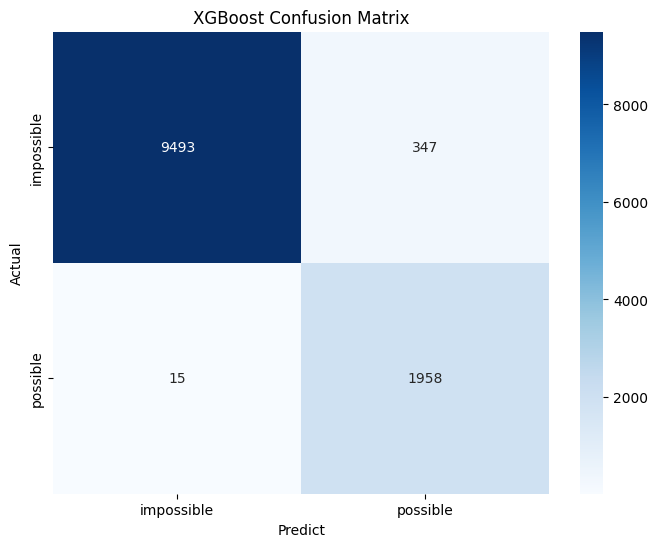

In [ ]:
# 모델 생성 및 실행
X = final_data[['pH', 'Temp', 'Current', 'Voltage', 'Current/Voltage', 'pH_diff',
                'Current_diff', 'Voltage_diff', 'Temp_diff', 'Temp_anomaly',
                'Current_anomaly', 'Voltage_anomaly', 'pH_anomaly']]
y = final_data['target']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50,stratify=y)

xc = XGBClassifier(random_state=50,max_depth=8,n_estimators=60, scale_pos_weight=len(X_train[y_train == 0]) / len(X_train[y_train == 1]))
xc.fit(X_train, y_train)
y_pred = xc.predict(X_test)

evaluate_model(y_test, y_pred, 'XGBoost')

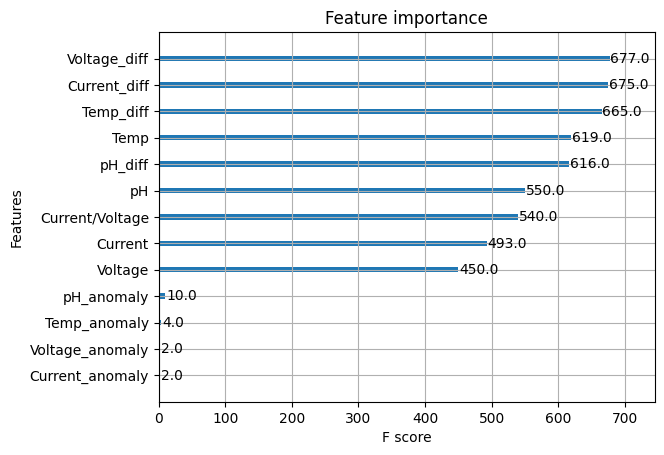

In [ ]:
# 공정 변수 중요도 분석
from xgboost import plot_importance

plot_importance(xc)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# 훈련 데이터에서의 성능 평가
y_train_pred = xc.predict(X_train)
print("훈련 데이터 Classification Report:")
print(classification_report(y_train, y_train_pred))

# 테스트 데이터에서의 성능은 이미 확인됨
print("테스트 데이터 Classification Report:")
print(classification_report(y_test, y_pred))


훈련 데이터 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     39357
           1       0.89      1.00      0.94      7894

    accuracy                           0.98     47251
   macro avg       0.95      0.99      0.97     47251
weighted avg       0.98      0.98      0.98     47251

테스트 데이터 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      9840
           1       0.85      0.99      0.92      1973

    accuracy                           0.97     11813
   macro avg       0.92      0.98      0.95     11813
weighted avg       0.97      0.97      0.97     11813



| 지표            | 훈련 데이터 성능 | 테스트 데이터 성능 | 차이  | 해석        |
|----------------|----------------|-------------------|------|-------------|
| **Accuracy**   | 0.98           | 0.97              | 0.01 | 차이가 작음  |
| **Precision(불량)** | 0.90           | 0.86              | 0.04 | 약간의 차이  |
| **Recall(불량)**    | 1.00           | 0.99              | 0.01 | 매우 작은 차이 |





현재 모델은 훈련 데이터와 테스트 데이터 간의 성능 차이가 작아 과적합 위험이 크지 않은 상태라고 볼 수 있다.

# pH 가설 검정

가설 1. pH가 정상 범위(1.5~3.0)를 벗어나는 경우 즉, ph가 3이상인 경우 불량 가능성이 높다.

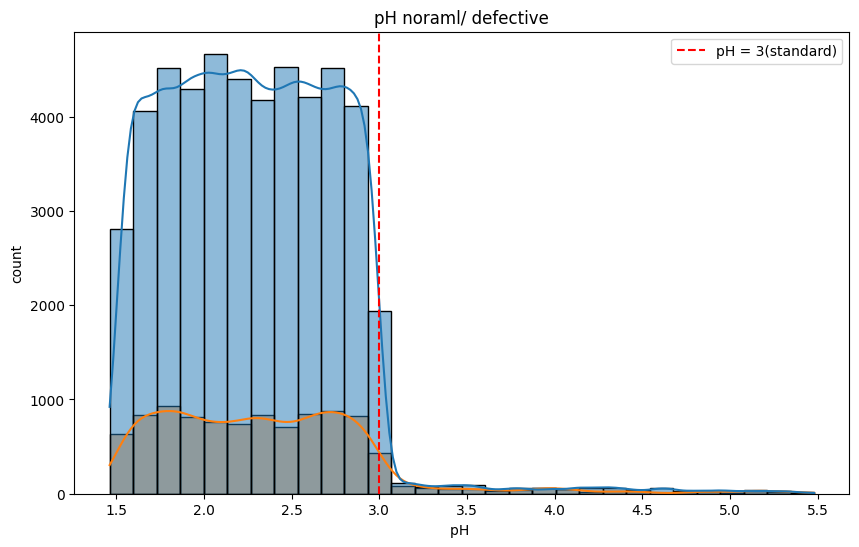

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# pH 값의 분포 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=final_data, x='pH', hue='target', bins=30, kde=True)
plt.axvline(x=3.0, color='red', linestyle='--', label='pH = 3(standard)')
plt.xlabel('pH ')
plt.ylabel('count')
plt.title('pH noraml/ defective')
plt.legend()
plt.show()


In [ ]:
from scipy.stats import chi2_contingency

# pH가 3 이상인 경우와 그 외 경우로 나누어 교차표 생성
table = pd.crosstab(final_data['pH_anomaly'], final_data['target'])

# 카이제곱 검정
chi2, p_value, dof, expected  = chi2_contingency(table)
print(f"카이제곱 검정 결과: chi2 = {chi2}, p-value = {p_value}")


카이제곱 검정 결과: chi2 = 702.6132625942769, p-value = 8.080431116603798e-155


## **pH 변수를 모델에 포함한 이유**

---

### **1. 시각적 증명**
- **pH ≤ 3.0 구간에서 정상 데이터의 균일한 분포**  
  - 정상 데이터는 **pH 1.5 ~ 3.0** 구간에서 균일하게 분포하고 있음
  - 이는 **도금 공정이 정상적으로 작동할 때 pH가 이 범위 내에 유지되어야 한다는 도메인 지식**과도 일치함

- **pH > 3.0 구간에서 불량 데이터 비중 증가**  
  - **pH가 3을 초과하면 불량 데이터의 비율이 급격히 증가**하는 경향을 보임
  - 특히, **pH가 3을 넘으면 정상 데이터의 비중이 급격히 감소**하고, 불량 데이터가 상대적으로 높은 비율을 차지함

---

### **2. 가설 검정**
- **귀무가설(H₀):** pH가 3 이상인지 여부와 불량 발생 여부 사이에 유의미한 관계가 없다.  
- **대립가설(H₁):** pH가 3 이상인지 여부와 불량 발생 여부 사이에 유의미한 관계가 있다.

- **카이제곱 검정 결과:**  
  - p-value가 매우 작게 나왔으므로 **귀무가설(H₀)을 기각**하고, **pH가 3 이상일 때 불량 발생률이 유의미하게 높아진다는 결론**을 도출할 수 있음.





# Current/Voltage 가설 검정

가설 2. Current/Voltage 비율은 공정 상태를 직접적으로 나타내는 변수이며, 특정 비율을 벗어날 경우, 도금 공정의 불균형 및 불량 발생 가능성이 높아진다.

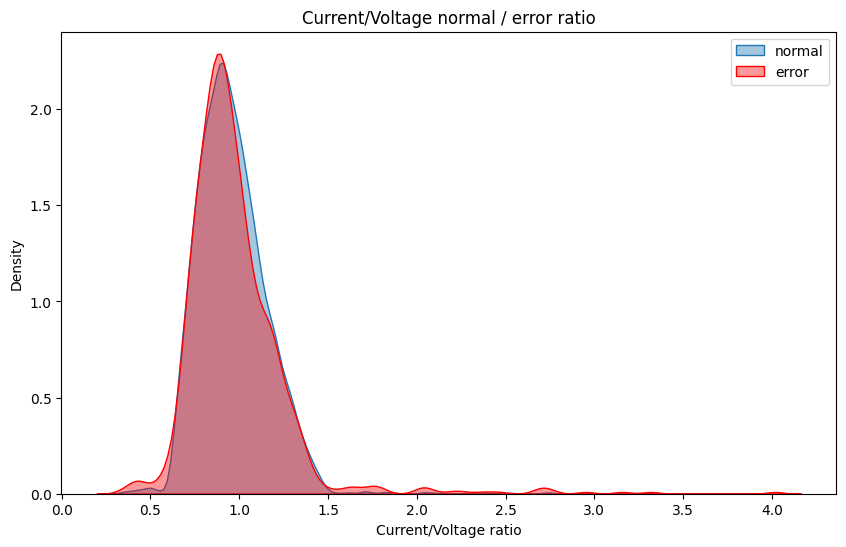

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=final_data[final_data['target'] == 0], x='Current/Voltage', label='normal', fill=True, alpha=0.4) # 정상 데이터
sns.kdeplot(data=final_data[final_data['target'] == 1], x='Current/Voltage', label='error', fill=True, alpha=0.4, color='red') # 불량 데이터
plt.xlabel('Current/Voltage ratio')
plt.title('Current/Voltage normal / error ratio')
plt.legend()
plt.show()

In [ ]:
from scipy.stats import ttest_ind

# 정상 데이터와 불량 데이터의 Current/Voltage 비율 추출
normal_ratio = final_data[final_data['target'] == 0]['Current/Voltage']
defective_ratio = final_data[final_data['target'] == 1]['Current/Voltage']

# T-검정
t_stat, p_value = ttest_ind(normal_ratio, defective_ratio, equal_var=False)

print(f"T-검정 결과: t-stat = {t_stat}, p-value = {p_value}")

T-검정 결과: t-stat = -4.972794497092092, p-value = 6.692744800887032e-07


## **Current/Voltage 비율 변수를 모델에 포함한 이유**

---

### **1. 시각적 증명**
- **정상 데이터:**  
  - 정상 데이터는 **0.9 ~ 1.1** 구간에서 가장 밀집되어 있으며, **1.0 부근에 중심을 두고 대칭적인 형태**를 보임.  
  - 이는 **정상적인 도금 공정에서는 전류와 전압이 일정한 비율로 유지되며, 큰 변동 없이 안정적**임을 의미함.

- **불량 데이터:**  
  - 불량 데이터는 **정상 데이터보다 넓은 범위에 걸쳐 분포**하며, 전류/전압 비율이 비정상적으로 높거나 낮은 경우가 많음.  
  - 이는 **도금 공정에서 전류가 과도하게 낮거나 전압이 비정상적으로 높아지면 공정 문제가 발생할 가능성이 높음**을 시사함.

---

### **2. 가설 검정**
- **귀무가설 (H₀):** 정상 데이터와 불량 데이터의 Current/Voltage 평균 비율에는 차이가 없다.  
- **대립가설 (H₁):** 정상 데이터와 불량 데이터의 Current/Voltage 평균 비율에는 유의미한 차이가 있다.

- **T-검정 결과:**  
  - p-value가 **0.05보다 훨씬 작게 나왔으므로**, 귀무가설(H₀)을 기각하고 대립가설(H₁)을 채택함.  
  - 따라서, **정상 데이터와 불량 데이터의 Current/Voltage 비율 평균에는 유의미한 차이가 있다**고 결론 지을 수 있음.






# Temp 가설 검정

가설 3. 시간에 따른 온도 변화량이 크거나 급격한 변화가 있을 경우, 도금 품질에 부정적인 영향을 미치고 불량 발생 가능성이 높아진다.

In [ ]:
from scipy.stats import ttest_ind

# Temp_diff가 높은 구간에서 정상과 불량 데이터의 평균 비교
normal_temp = final_data[final_data['target'] == 0]['Temp_diff']
defective_temp = final_data[final_data['target'] == 1]['Temp_diff']

t_stat, p_value = ttest_ind(normal_temp, defective_temp, equal_var=False)
print(f"T-검정 결과: t-stat = {t_stat}, p-value = {p_value}")

T-검정 결과: t-stat = 0.06489427504768151, p-value = 0.9482591069960431


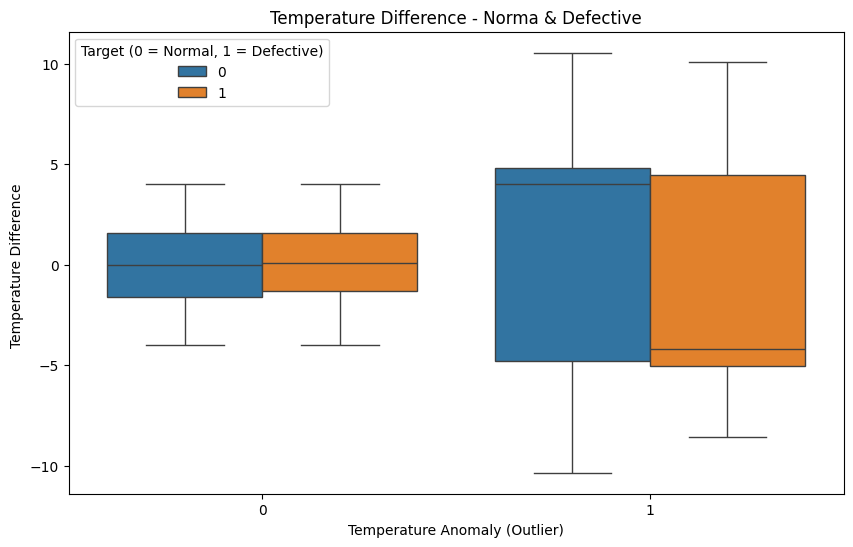

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=final_data, x='Temp_anomaly', y='Temp_diff', hue='target')
plt.xlabel('Temperature Anomaly (Outlier)')
plt.ylabel('Temperature Difference ')
plt.title('Temperature Difference - Norma & Defective' )
plt.legend(title='Target (0 = Normal, 1 = Defective)')
plt.show()

## **온도 변수(Temp_diff, Temp_anomaly)를 모델에 포함한 이유**

---

### **1. 데이터 해석**
- **온도 변화량(Temp_diff)의 평균 차이 검정:**  
  - 정상 데이터와 불량 데이터 간의 온도 변화량 평균에 대한 T-검정을 수행한 결과:  
    - **귀무가설 (H₀):** 정상 데이터와 불량 데이터 간 Temp_diff 평균에는 차이가 없다.  
    - **대립가설 (H₁):** 정상 데이터와 불량 데이터 간 Temp_diff 평균에는 차이가 있다.

  - **검정 결과:**  
    - p-value가 **0.05보다 크기 때문에 귀무가설(H₀)을 기각하지 못함**.  
    - 즉, **Temp_diff 평균 간에 유의미한 차이는 없다고 해석할 수 있음.**

---

### **2. 한계점 및 비선형적 해석 필요성**
- **T-검정은 선형적 관계에 주로 적용**되기 때문에, 단순한 평균 차이 검정만으로 온도 변화가 불량에 영향을 미치지 않는다고 결론 내리기는 어려움.  
- **온도 변화의 비선형적 영향을 반영하기 위해 Temp_anomaly에 따른 불량 정상 데이터를 시각화 해봄.

---

### **3. Temp_anomaly에 따른 데이터 해석**
- **이상치 구간(Temp_anomaly = 1)에서의 해석:**  
  - **이상치 구간(Temp_anomaly = 1)에서 불량 데이터(주황색)의 중앙값이 정상 데이터(파란색)의 중앙값의 차이가 큼.  
  - 이는 **불량 데이터의 평균적인 온도 변화량이 정상 데이터와 차이가 크다는 것을 의미**하며, 온도 변화가 불량 발생에 중요한 역할을 할 가능성이 높음을 시사함.


